In [8]:
import pandas as pd
import numpy as np

In [2]:
sales = pd.DataFrame({
    "date": pd.to_datetime([
        "2025-01-02","2025-01-02","2025-01-03","2025-01-03","2025-01-04","2025-01-04",
        "2025-02-01","2025-02-01","2025-02-02","2025-02-02","2025-02-03","2025-02-03"
    ]),
    "region": ["North","North","South","South","North","South","North","South","North","South","North","South"],
    "channel": ["Online","Store","Online","Store","Store","Online","Online","Online","Store","Store","Online","Store"],
    "category": ["Bikes","Bikes","Accessories","Bikes","Accessories","Accessories","Bikes","Accessories","Bikes","Accessories","Accessories","Bikes"],
    "units": [2, 1, 5, 1, 3, 2, 1, 4, 2, 1, 6, 1],
    "unit_price": [800, 820, 25, 810, 30, 28, 790, 26, 815, 32, 27, 805],
    "discount": [0.05, 0.00, 0.10, 0.00, 0.00, 0.05, 0.00, 0.15, 0.00, 0.00, 0.10, 0.00],
})
 
 
sales.head()

,date,region,channel,category,units,unit_price,discount
0,2025-01-02,North,Online,Bikes,2,800,0.05
1,2025-01-02,North,Store,Bikes,1,820,0.00
2,2025-01-03,South,Online,Accessories,5,25,0.10
3,2025-01-03,South,Store,Bikes,1,810,0.00
4,2025-01-04,North,Store,Accessories,3,30,0.00


In [5]:
sales.dtypes

date          datetime64[us]
region                   str
channel                  str
category                 str
units                  int64
unit_price             int64
discount             float64
dtype: object

In [6]:
sales.describe

<bound method NDFrame.describe of          date region channel     category  units  unit_price  discount
0  2025-01-02  North  Online        Bikes      2         800      0.05
1  2025-01-02  North   Store        Bikes      1         820      0.00
2  2025-01-03  South  Online  Accessories      5          25      0.10
3  2025-01-03  South   Store        Bikes      1         810      0.00
4  2025-01-04  North   Store  Accessories      3          30      0.00
5  2025-01-04  South  Online  Accessories      2          28      0.05
6  2025-02-01  North  Online        Bikes      1         790      0.00
7  2025-02-01  South  Online  Accessories      4          26      0.15
8  2025-02-02  North   Store        Bikes      2         815      0.00
9  2025-02-02  South   Store  Accessories      1          32      0.00
10 2025-02-03  North  Online  Accessories      6          27      0.10
11 2025-02-03  South   Store        Bikes      1         805      0.00>

In [7]:
# Pajamos po nuolaidos (paprasta formulė)
sales["revenue"] = (sales["units"] * sales["unit_price"] * (1 - sales["discount"])).round(2)
 
sales.head()

,date,region,channel,category,units,unit_price,discount,revenue
0,2025-01-02,North,Online,Bikes,2,800,0.05,1520.0
1,2025-01-02,North,Store,Bikes,1,820,0.00,820.0
2,2025-01-03,South,Online,Accessories,5,25,0.10,112.5
3,2025-01-03,South,Store,Bikes,1,810,0.00,810.0
4,2025-01-04,North,Store,Accessories,3,30,0.00,90.0


In [9]:
sales.dtypes

date          datetime64[us]
region                   str
channel                  str
category                 str
units                  int64
unit_price             int64
discount             float64
revenue              float64
dtype: object

In [11]:
# Santrauka per visą lentelę
total_revenue = sales["revenue"].sum().round(2)
avg_units = sales["units"].mean().round(2)
orders_count = len(sales)
 
total_revenue, avg_units, orders_count

(np.float64(6896.9), np.float64(2.42), 12)

In [12]:
rev_by_region = sales.groupby("region")["revenue"].sum()
rev_by_region

region
North    4995.8
South    1901.1
Name: revenue, dtype: float64

In [13]:
# Jei rezultato reikia kaip DataFrame
rev_by_region_df = rev_by_region.reset_index(name="total_revenue")
rev_by_region_df

,region,total_revenue
0,North,4995.8
1,South,1901.1


In [14]:
# Pajamos pagal regioną ir kanalą
rev_by_region_channel = (
    sales.groupby(["region", "channel"])["revenue"]
    .sum()
    .sort_values(ascending=False)
)
rev_by_region_channel

region  channel
North   Store      2540.0
        Online     2455.8
South   Store      1647.0
        Online      254.1
Name: revenue, dtype: float64

In [15]:
# MultiIndex -> platus formatas (stulpeliai pagal kanalą)
rev_wide = rev_by_region_channel.unstack(fill_value=0)
rev_wide

channel,Online,Store
region,,
North,2455.8,2540.0
South,254.1,1647.0


In [16]:
# Kelios agregacijos vienam stulpeliui
agg_revenue = sales.groupby("region")["revenue"].agg(["sum", "mean", "count"])
agg_revenue

,sum,mean,count
region,,,
North,4995.8,832.633333,6
South,1901.1,316.850000,6


In [17]:
agg_multi = (
    sales.groupby(["region", "channel"])
    .agg({
        "revenue": ["sum", "mean"],
        "units": ["sum", "mean"],
        "unit_price": "mean",
        "discount": "mean",
    })
)
 
# Patogumui: apvalinimas
agg_multi.round(2)

revenue         units       unit_price discount
                   sum    mean   sum  mean       mean     mean
region channel                                                
North  Online   2455.8  818.60     9  3.00     539.00     0.05
       Store    2540.0  846.67     6  2.00     555.00     0.00
South  Online    254.1   84.70    11  3.67      26.33     0.10
       Store    1647.0  549.00     3  1.00     549.00     0.00

In [18]:
summary = (
    sales.groupby(["region", "channel"])
    .agg(
        total_revenue=("revenue", "sum"),
        avg_revenue=("revenue", "mean"),
        total_units=("units", "sum"),
        avg_units=("units", "mean"),
        avg_price=("unit_price", "mean"),
        avg_discount=("discount", "mean"),
        orders=("revenue", "count"),
    )
    .round(2)
    .reset_index()
)
 
summary

,region,channel,total_revenue,avg_revenue,total_units,avg_units,avg_price,avg_discount,orders
0,North,Online,2455.8,818.60,9,3.00,539.00,0.05,3
1,North,Store,2540.0,846.67,6,2.00,555.00,0.00,3
2,South,Online,254.1,84.70,11,3.67,26.33,0.10,3
3,South,Store,1647.0,549.00,3,1.00,549.00,0.00,3


In [19]:
pivot_rev = pd.pivot_table(
    sales,
    index="region",
    columns="channel",
    values="revenue",
    aggfunc="sum",
    fill_value=0
)
 
pivot_rev

channel,Online,Store
region,,
North,2455.8,2540.0
South,254.1,1647.0


In [20]:
# Tas pats rezultatas kaip pivot lentelėje, tik per groupby + unstack
groupby_like_pivot = (
    sales.groupby(["region", "channel"])["revenue"]
    .sum()
    .unstack(fill_value=0)
)
 
groupby_like_pivot

channel,Online,Store
region,,
North,2455.8,2540.0
South,254.1,1647.0


In [21]:
# Paruošiama „plataus“ formato lentelė: pajamos pagal regioną ir kanalą
wide = pivot_rev.reset_index()
wide

channel,region,Online,Store
0,North,2455.8,2540.0
1,South,254.1,1647.0


In [22]:
# Wide -> Long
long = wide.melt(
    id_vars=["region"],
    var_name="channel",
    value_name="total_revenue"
)
 
long

,region,channel,total_revenue
0,North,Online,2455.8
1,South,Online,254.1
2,North,Store,2540.0
3,South,Store,1647.0


In [23]:
sales = pd.DataFrame({
    "date": pd.to_datetime([
        "2025-01-01","2025-01-02","2025-01-03","2025-01-04","2025-01-05",
        "2025-01-06","2025-01-07","2025-01-08"
    ]),
    "region": ["North","North","South","South","North","South","North","South"],
    "revenue": [1200, 1500, 900, 1100, 1600, 1000, 1700, 1300]
})
 
sales

,date,region,revenue
0,2025-01-01,North,1200
1,2025-01-02,North,1500
2,2025-01-03,South,900
3,2025-01-04,South,1100
4,2025-01-05,North,1600
5,2025-01-06,South,1000
6,2025-01-07,North,1700
7,2025-01-08,South,1300


NameError: name 'plt' is not defined

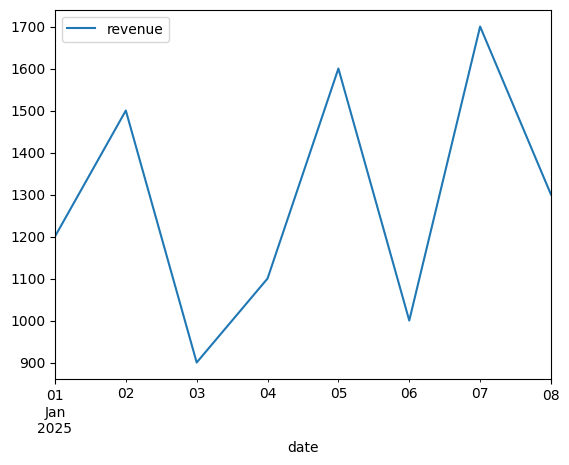

In [24]:
sales.plot(x="date", y="revenue")
plt.show()

NameError: name 'plt' is not defined

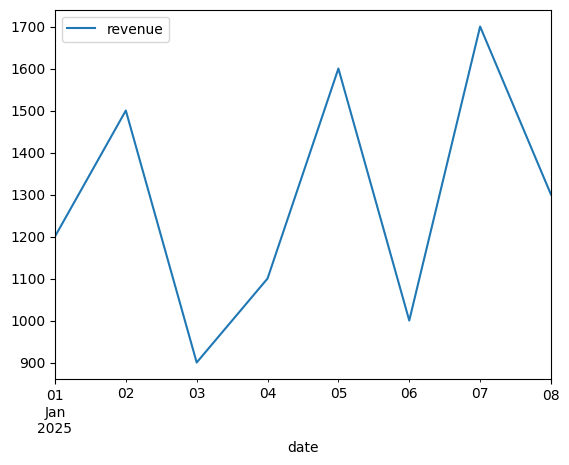

In [25]:
sales.plot(x="date", y="revenue")
plt.title("Pardavimų dinamika laike")
plt.xlabel("Data")
plt.ylabel("Pajamos")
plt.show()

NameError: name 'plt' is not defined

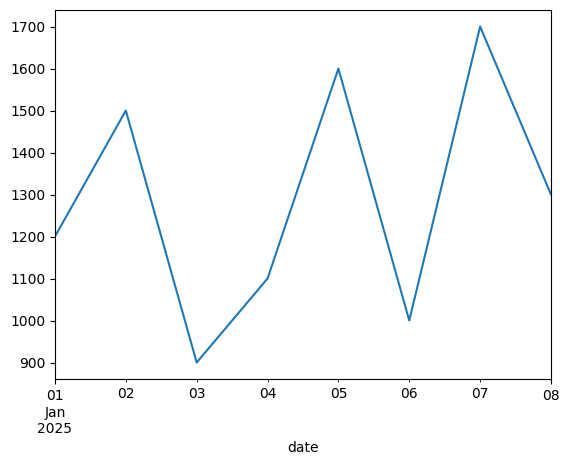

In [26]:
daily_revenue = sales.set_index("date")["revenue"]
daily_revenue.plot()
plt.title("Dienos pajamos")
plt.show()

NameError: name 'plt' is not defined

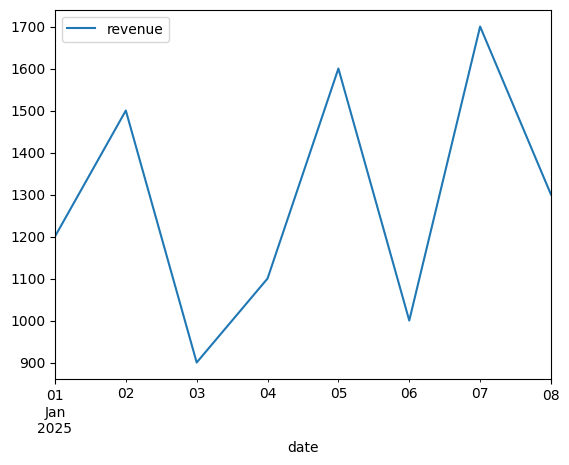

In [27]:
sales.plot(x="date", y="revenue")
plt.title("Pardavimų dinamika")
plt.savefig("sales_trend.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
data = {
    "date": [
        "2025-01-01", "2025-01-02", "2025-01-03",
        "2025-01-05", "2025-01-06",
        "2025-01-09", "2025-01-10"
    ],
    "revenue": [1200, 1300, 1250, 1400, 1500, 1600, 1550]
}
 
df = pd.DataFrame(data)
df

,date,revenue
0,2025-01-01,1200
1,2025-01-02,1300
2,2025-01-03,1250
3,2025-01-05,1400
4,2025-01-06,1500
5,2025-01-09,1600
6,2025-01-10,1550


In [11]:
df["date"] = pd.to_datetime(df["date"])

In [12]:

df["date_str"] = df["date"].dt.strftime("%Y-%m-%d")
df

,date,revenue,date_str
0,2025-01-01,1200,2025-01-01
1,2025-01-02,1300,2025-01-02
2,2025-01-03,1250,2025-01-03
3,2025-01-05,1400,2025-01-05
4,2025-01-06,1500,2025-01-06
5,2025-01-09,1600,2025-01-09
6,2025-01-10,1550,2025-01-10


In [13]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["weekday"] = df["date"].dt.day_name()
 
df

,date,revenue,date_str,year,month,day,weekday
0,2025-01-01,1200,2025-01-01,2025,1,1,Wednesday
1,2025-01-02,1300,2025-01-02,2025,1,2,Thursday
2,2025-01-03,1250,2025-01-03,2025,1,3,Friday
3,2025-01-05,1400,2025-01-05,2025,1,5,Sunday
4,2025-01-06,1500,2025-01-06,2025,1,6,Monday
5,2025-01-09,1600,2025-01-09,2025,1,9,Thursday
6,2025-01-10,1550,2025-01-10,2025,1,10,Friday


In [15]:
df["prev_date"] = df["date"].shift(1)
df["days_since_prev"] = df["date"] - df["prev_date"]
 
df

,date,revenue,date_str,year,month,day,weekday,prev_date,days_since_prev
0,2025-01-01,1200,2025-01-01,2025,1,1,Wednesday,NaT,NaT
1,2025-01-02,1300,2025-01-02,2025,1,2,Thursday,2025-01-01,1 days
2,2025-01-03,1250,2025-01-03,2025,1,3,Friday,2025-01-02,1 days
3,2025-01-05,1400,2025-01-05,2025,1,5,Sunday,2025-01-03,2 days
4,2025-01-06,1500,2025-01-06,2025,1,6,Monday,2025-01-05,1 days
5,2025-01-09,1600,2025-01-09,2025,1,9,Thursday,2025-01-06,3 days
6,2025-01-10,1550,2025-01-10,2025,1,10,Friday,2025-01-09,1 days


In [16]:
# Nustatomas laiko indeksas
ts = df.set_index("date")[["revenue"]]
 
# Sukuriama pilna dienų seka
ts_daily = ts.asfreq("D")
ts_daily

,revenue
date,
2025-01-01,1200.0
2025-01-02,1300.0
2025-01-03,1250.0
2025-01-04,NaN
2025-01-05,1400.0
2025-01-06,1500.0
2025-01-07,NaN
2025-01-08,NaN
2025-01-09,1600.0


In [17]:
# Paprastas trūkstamų reikšmių tvarkymas
ts_daily["revenue_filled"] = ts_daily["revenue"].fillna(0)
ts_daily

,revenue,revenue_filled
date,,
2025-01-01,1200.0,1200.0
2025-01-02,1300.0,1300.0
2025-01-03,1250.0,1250.0
2025-01-04,NaN,0.0
2025-01-05,1400.0,1400.0
2025-01-06,1500.0,1500.0
2025-01-07,NaN,0.0
2025-01-08,NaN,0.0
2025-01-09,1600.0,1600.0


In [18]:
# Savaitinis agregavimas
weekly = ts_daily["revenue"].resample("W").sum()
weekly

date
2025-01-05    5150.0
2025-01-12    4650.0
Freq: W-SUN, Name: revenue, dtype: float64

In [20]:
# Mėnesinis vidurkis
monthly_avg = ts_daily["revenue"].resample("ME").mean()
monthly_avg

date
2025-01-31    1400.0
Freq: ME, Name: revenue, dtype: float64

In [21]:
# 3 dienų slenkantis vidurkis
ts_daily["rolling_3d_avg"] = ts_daily["revenue"].rolling(window=3).mean()
ts_daily

,revenue,revenue_filled,rolling_3d_avg
date,,,
2025-01-01,1200.0,1200.0,NaN
2025-01-02,1300.0,1300.0,NaN
2025-01-03,1250.0,1250.0,1250.0
2025-01-04,NaN,0.0,NaN
2025-01-05,1400.0,1400.0,NaN
2025-01-06,1500.0,1500.0,NaN
2025-01-07,NaN,0.0,NaN
2025-01-08,NaN,0.0,NaN
2025-01-09,1600.0,1600.0,NaN
